In [16]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import torch.optim.lr_scheduler as lr_scheduler
from python_scripts.sgr_utils import *
from python_scripts.plotting import *
from scipy.special import gammaln
import warnings
from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings("ignore", category=MatplotlibDeprecationWarning)

print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: False


In [17]:
sgr_df = pickle.load(open('../CIFAR2/sgr_set_cnn','rb')) 
sgr_df = sgr_df.sample(frac=1, random_state=42)
print(sgr_df.shape)
sgr_df.head() # balanced CIFAR-2 dataset

(7000, 3)


,y_true,y_pred,SR
6500,0.0,0.0,0.929581
2944,0.0,0.0,0.982615
2024,1.0,1.0,0.542768
263,0.0,0.0,0.822609
4350,0.0,0.0,0.953512


In [18]:
delta = 0.001

### <font color = 'yellow'> Evolution of bounds with $\theta$

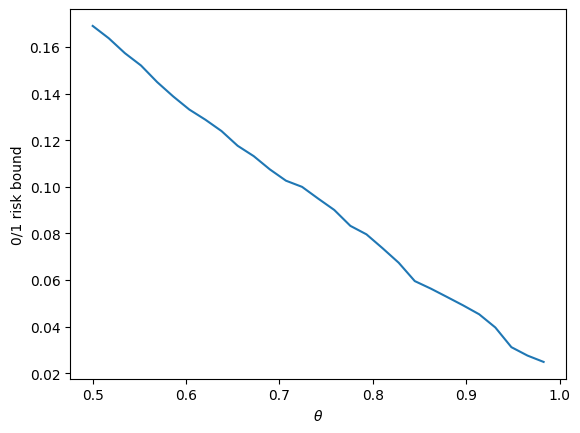

In [4]:
thetas, bounds = bound_evo_w_theta('standard', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('0/1 risk bound')
plt.show()

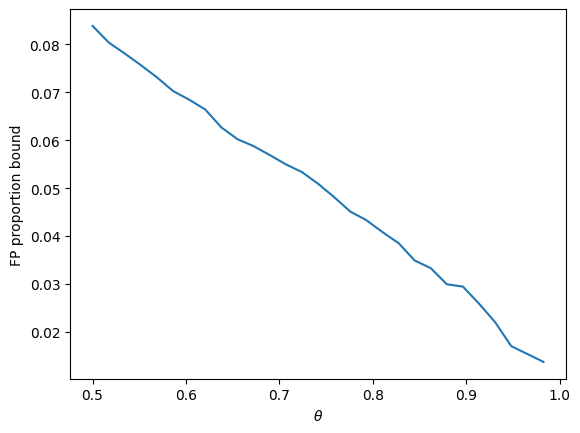

In [5]:
thetas, bounds = bound_evo_w_theta('FP', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('FP proportion bound')
plt.show()

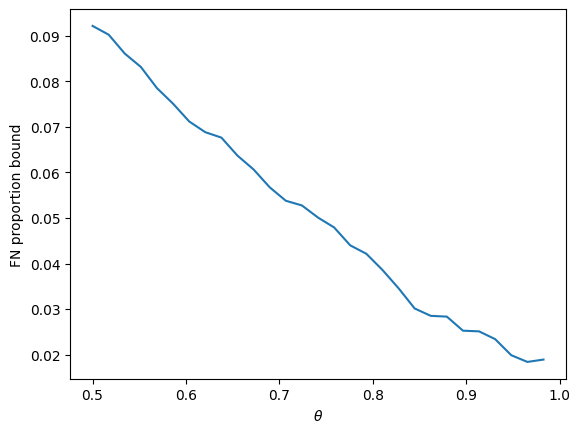

In [6]:
thetas, bounds = bound_evo_w_theta('FN', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('FN proportion bound')
plt.show()

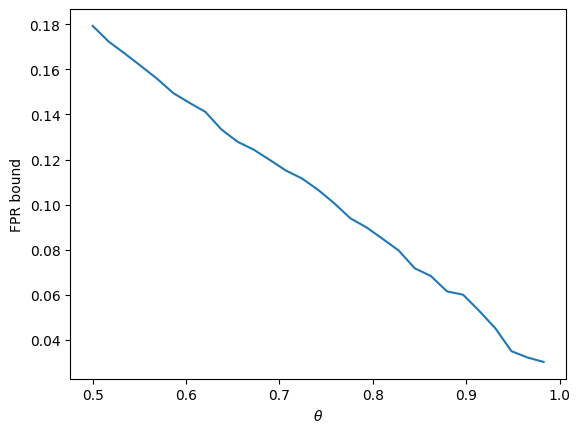

In [7]:
thetas, bounds = bound_evo_w_theta('FPR', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('FPR bound')
plt.show()

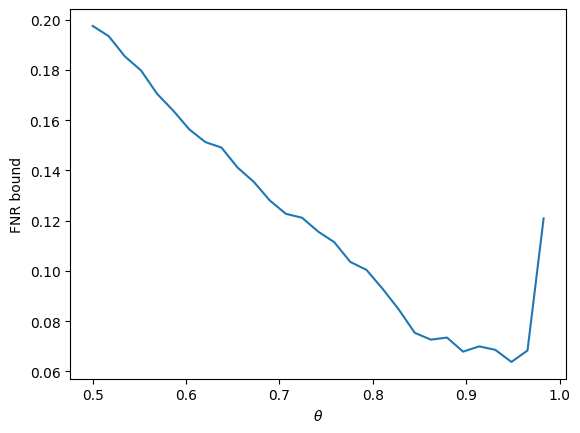

In [8]:
thetas, bounds = bound_evo_w_theta('FNR', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('FNR bound')
plt.show()

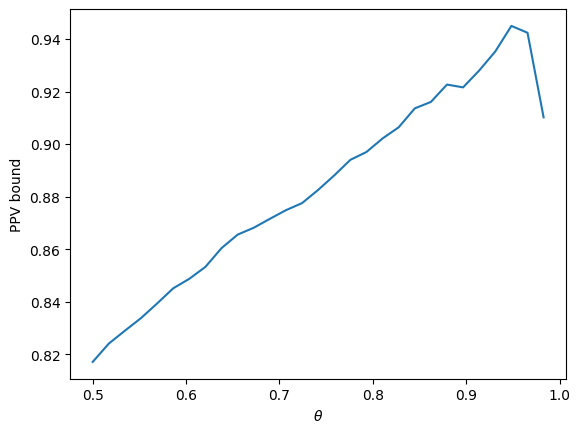

In [9]:
thetas, bounds = bound_evo_w_theta('PPV', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('PPV bound')
plt.show()

In [55]:
metrics_and_targets = {'standard' : 0.1,
                       'PPV' : 0.9,
                       'SE': 0.8}

In [65]:

def joint_control(metrics_and_targets, sgr_df, delta, plot=False, steps=100):

    metric_sign_mapping = {'standard': '<',
                           'FP': '<', 'FN': '<',
                           'FPR': '<', 'FNR': '<',
                           'PPV': '>', 'SE': '>',
                           'SP': '>'}
    y_proj = -0.01
    projection_handles = []

    # Use a colormap to assign a unique color to each metric
    num_metrics = len(metrics_and_targets)
    color_map = cm.get_cmap('tab10', num_metrics)
    colors = [color_map(i) for i in range(num_metrics)]
    segments_per_metric = {key: [] for key in metrics_and_targets.keys()}

    if plot:
        plt.figure()

    for i, (metric, target) in enumerate(metrics_and_targets.items()):
        thetas, bounds = bound_evo_w_theta(metric, sgr_df, delta, steps=steps)
        color = colors[i]

        if metric_sign_mapping[metric] == '>':
                mask = (np.array(bounds) > target)
        else:
            mask = (np.array(bounds) < target)

        segments = get_segments(thetas, mask)
        segments_per_metric[metric] = segments

        if plot:
            plt.plot(thetas, bounds, color=color, label=f'{metric} bound')
            plt.axhline(y=target, color=color, linestyle='--', label=f'{metric} target')
            plt.xlabel(r'$\theta$')
            plt.ylabel('Metric bounds')
            plt.tick_params(axis='y')

            for (x_start, x_end) in segments:
                plt.hlines(y_proj, x_start, x_end, colors=color, linewidth=4)

            # Legend handle for projections
            projection_handles.append(
                Line2D([0], [0], color=color, linewidth=4, label=r'$\theta$ '+ f'/ {metric} {metric_sign_mapping[metric]} {target}')
            )

    if plot:
        plt.ylim(bottom=y_proj - 0.02)
        plt.legend(handles=projection_handles, loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    if not plot:
        return segments_per_metric


In [66]:
out = joint_control(metrics_and_targets, sgr_df, delta, plot=False)

In [67]:
out

{'standard': [(np.float64(0.7273014783859253), np.float64(0.994947804345025))],
 'PPV': [(np.float64(0.803050438563029), np.float64(0.9797980123096042))],
 'SE': [(np.float64(0.5000545978546143), np.float64(0.9848479429880779)),
  (np.float64(0.994947804345025), np.float64(0.994947804345025))]}

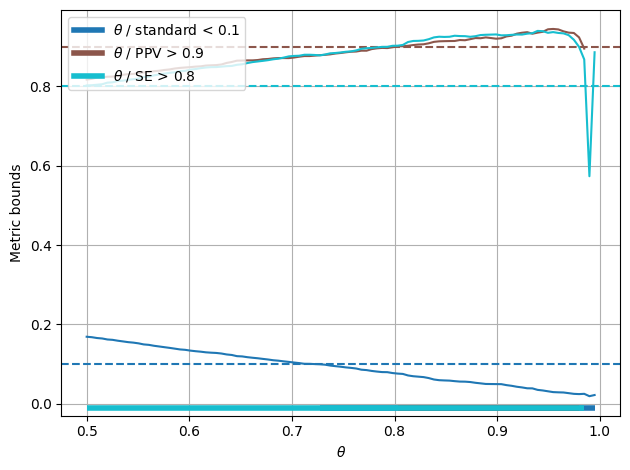

In [68]:
joint_control(metrics_and_targets, sgr_df, delta, plot=True)

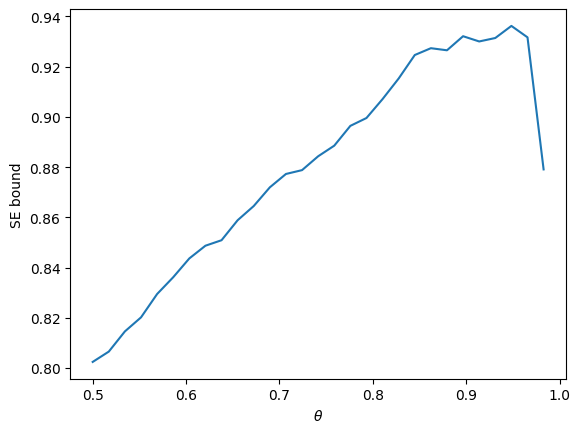

In [11]:
thetas, bounds = bound_evo_w_theta('SE', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('SE bound')
plt.show()

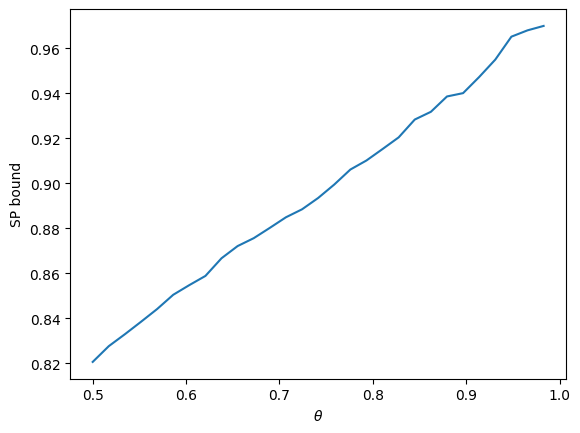

In [12]:
thetas, bounds = bound_evo_w_theta('SP', sgr_df, delta,steps=30)
plt.plot(thetas, bounds)
plt.xlabel(r'$\theta$')
plt.ylabel('SP bound')
plt.show()

### <font color='yellow'> Evolution of proportion of 1s in selected samples with $\theta$

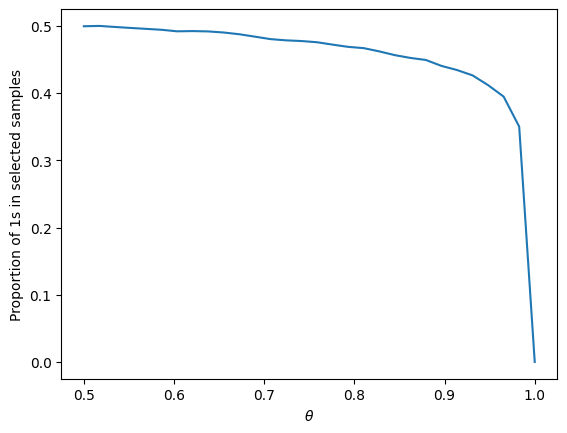

In [13]:
thetas, pos_propors = pos_propor_w_theta(sgr_df, steps=30)
plt.plot(thetas, pos_propors)
plt.xlabel(r'$\theta$')
plt.ylabel('Proportion of 1s in selected samples')
plt.show()

__Comment__: 1s proportion concave drop when demanded classifier confidence gets close to 1 means that classifier tends to be highly confident in its class-0/airplane predictions more than in its class-1/car predictions. 

In other words, facing equal numbers of airplane pictures and car pictures, the classifier will say "I'm sure this picture is an airplane" a lot more often than "I'm sure this picture is a car"  

### <font color = 'yellow'> Evolution of best monotonous bound with $\theta_M$

In [14]:
theta_Ms = []
lowest_bounds = []
for theta_M in np.linspace(sgr_df.SR.min(), sgr_df.SR.max(), 15):
    if sgr_df.loc[sgr_df.SR >= theta_M].shape[0] <= sgr_df.y_true.sum() + np.sqrt(-np.log(delta/2)/2):
        continue
    else: # constraint verified
        theta_Ms.append(theta_M)
        denominator = 1- (sgr_df.y_true.sum() + np.sqrt(-np.log(delta/2)/2))/sgr_df.loc[sgr_df.SR >= theta_M].shape[0]
        bounds = []
        for theta in np.linspace(sgr_df.SR.min(), theta_M, 100):
            selected_samples = sgr_df.loc[sgr_df.SR >= theta].copy()
            e = ((selected_samples.y_true==0) & (selected_samples.y_pred==1)).sum()
            b_FP = B_star(delta, e, selected_samples.shape[0])
            bounds.append(b_FP/denominator)
        lowest_bounds.append(np.min(bounds))


KeyboardInterrupt: 

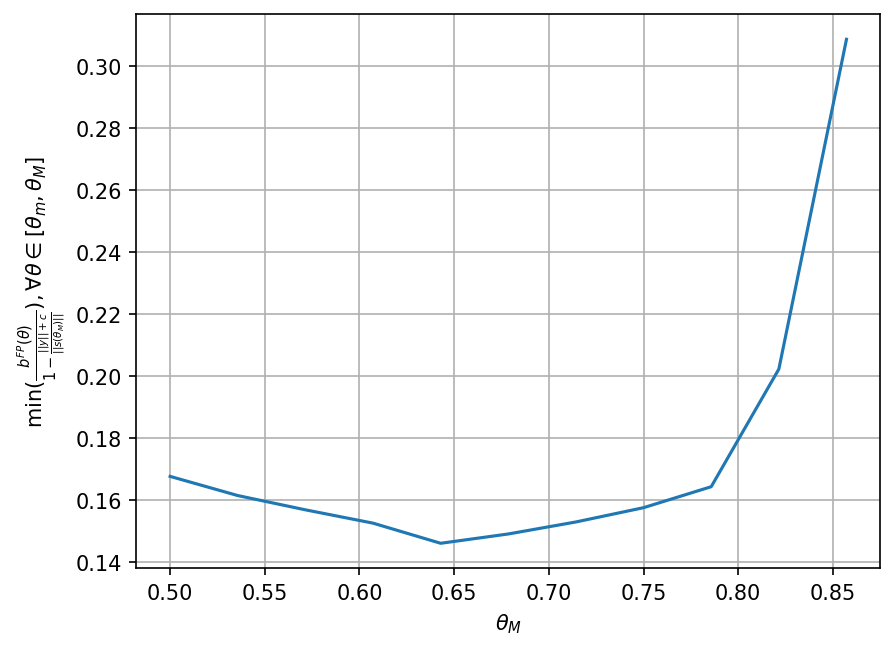

In [ ]:
plt.figure(dpi=150)
plt.plot(theta_Ms, lowest_bounds)
plt.xlabel(r'$\theta_M$')
plt.ylabel(r'$\text{min}(\frac{b^{FP}(\theta)}{1-\frac{||y||+c}{||s(\theta_M)||}}), \forall \theta \in [\theta_m, \theta_M]$')
plt.grid()
plt.show()